<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/04_salmonellosis_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salmonellosis Machine Learning & Deep Learning

## Imports

In [111]:
!pip install -q keras-tuner

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [113]:
# sklearn
from sklearn.model_selection import GridSearchCV,train_test_split, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn import set_config


set_config(transform_output='pandas')
pd.set_option("display.max_rows", None)

In [114]:
# tensorflow
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# keras
import keras_tuner as kt
from tensorflow.keras.regularizers import l1_l2

## Custom Functions

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_linear_coefficients(
    fitted_pipeline,
    top_n=10,
    include_intercept=False,
    friendly_names=None,
    title="Factors Most Associated With Weekly Cases",
    figsize=(11, 7),
):

    # Get preprocessing and regression steps
    preprocessor = fitted_pipeline[-2]
    model = fitted_pipeline[-1]

    # Create coefficient table
    coefficients = pd.DataFrame({
        "Feature": preprocessor.get_feature_names_out(),
        "Coefficient": model.coef_,
    })

    # Clean feature names
    coefficients["Feature"] = (
        coefficients["Feature"]
        .str.replace(r"^[^_]+__", "", regex=True)
        .str.replace(
            r"^Reporting Area_(.+)$",
            r"Reporting area: \1",
            regex=True,
        )
        .str.replace(
            r"^Season_(.+)$",
            r"Season: \1",
            regex=True,
        )
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    # Stakeholder-friendly names
    default_names = {
        "Previous Week Cases": "Cases last week",
        "Previous 52 Week Max":
            "Highest week in the previous year",
        "Cumulative Ytd Previous Mmwr Year":
            "Previous-year cases reported by this point",
    }

    coefficients["Feature"] = coefficients["Feature"].replace(
        default_names
    )

    # Apply additional user-provided names
    if friendly_names is not None:
        coefficients["Feature"] = coefficients["Feature"].replace(
            friendly_names
        )

    # Add intercept when requested
    if include_intercept:
        coefficients.loc[len(coefficients)] = [
            "Starting estimate",
            model.intercept_,
        ]

    # Separate seasons from other factors
    is_season = coefficients["Feature"].str.startswith("Season:")

    season_rows = coefficients[is_season]
    other_rows = coefficients[~is_season]

    # Select strongest non-season factors
    strongest_rows = (
        other_rows
        .assign(Absolute=other_rows["Coefficient"].abs())
        .nlargest(top_n, "Absolute")
        .drop(columns="Absolute")
    )

    # Combine strongest factors with all seasons
    plot_data = (
        pd.concat([strongest_rows, season_rows])
        .drop_duplicates(subset="Feature")
        .sort_values("Coefficient")
        .reset_index(drop=True)
    )

    # Bar colors
    positive_color = "#45B8AC"
    negative_color = "#8A7AAE"

    colors = np.where(
        plot_data["Coefficient"] >= 0,
        positive_color,
        negative_color,
    )

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(
        plot_data["Feature"],
        plot_data["Coefficient"],
        color=colors,
        height=0.68,
    )

    # Zero reference line
    ax.axvline(
        0,
        color="#666666",
        linewidth=1,
    )

    # Space between each bar and its annotation
    max_value = max(
        plot_data["Coefficient"].abs().max(),
        1,
    )

    annotation_gap = max_value * 0.025

    # Add margins for annotations on both sides
    ax.set_xlim(
        min(plot_data["Coefficient"].min(), 0)
        - max_value * 0.25,

        max(plot_data["Coefficient"].max(), 0)
        + max_value * 0.25,
    )

    # Annotate the bars
    for bar, value in zip(
        bars,
        plot_data["Coefficient"],
    ):
        if value >= 0:
            x_position = value + annotation_gap
            alignment = "left"
        else:
            x_position = value - annotation_gap
            alignment = "right"

        ax.text(
            x_position,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+,.1f}",
            va="center",
            ha=alignment,
            fontsize=10,
            fontweight="semibold",
            color="#333333",
        )

    # Title
    ax.set_title(
        title,
        fontsize=17,
        fontweight="bold",
        loc="left",
        pad=18,
    )

    # Axis labels
    ax.set_xlabel(
        "Estimated difference in weekly reported cases",
        labelpad=10,
    )

    ax.set_ylabel("")

    # Grid
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.20,
    )

    ax.set_axisbelow(True)

    # Remove unnecessary borders
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)

    ax.spines["bottom"].set_color("#CCCCCC")

    ax.tick_params(
        axis="y",
        length=0,
        labelsize=10,
    )

    ax.tick_params(
        axis="x",
        colors="#666666",
    )

    # Add vertical spacing
    ax.margins(y=0.06)

    # Add space for names and annotations
    plt.subplots_adjust(
        left=0.30,
        right=0.95,
        top=0.86,
        bottom=0.12,
    )

    plt.show()

    return coefficients

In [164]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6, 12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    # Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics), figsize=figsize)

    # If there is only one metric, make axes iterable
    if len(metrics) == 1:
        axes = [axes]

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]

        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(
            epochs,
            metric_values,
            label=metric_name,
            marker=marker
        )

        # Check if val_{metric} exists. If so, plot it.
        val_metric_name = f"val_{metric_name}"

        if val_metric_name in history.history:

            # Get validation values and plot
            metric_values = history.history[val_metric_name]

            ax.plot(
                epochs,
                metric_values,
                label=val_metric_name,
                marker=marker
            )

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)

    fig.tight_layout()

    return fig, axes

In [116]:
def calculate_metrics(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r_squared = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r_squared,
    }


In [117]:
def evaluate_regression(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name,
    neural_network=False
):
    # TensorFlow predict() uses verbose
    if neural_network:
        train_predictions = model.predict(
            X_train,
            verbose=0
        ).flatten()

        test_predictions = model.predict(
            X_test,
            verbose=0
        ).flatten()

    # Scikit-learn models
    else:
        train_predictions = model.predict(X_train)
        test_predictions = model.predict(X_test)

    # Calculate training metrics
    train_metrics = calculate_metrics(
        y_true=y_train,
        y_pred=train_predictions,
        model_name=model_name
    )

    # Calculate testing metrics
    test_metrics = calculate_metrics(
        y_true=y_test,
        y_pred=test_predictions,
        model_name=model_name
    )

    # Add dataset labels
    train_metrics["Data"] = "Train"
    test_metrics["Data"] = "Test"

    # Create one results table
    results = pd.DataFrame([
        train_metrics,
        test_metrics
    ])

    # Arrange the columns
    results = results[
        ["Model", "Data", "MAE", "RMSE", "R²"]
    ]

    return results.round(3)

## Load and Prepare Data

In [118]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17079 entries, 0 to 17078
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Reporting Area                     17079 non-null  object 
 1   Current MMWR Year                  17079 non-null  int64  
 2   MMWR WEEK                          17079 non-null  int64  
 3   Label                              17079 non-null  object 
 4   Current week                       17079 non-null  int64  
 5   Previous 52 week Max               17079 non-null  float64
 6   Cumulative YTD Current MMWR Year   17079 non-null  int64  
 7   Cumulative YTD Previous MMWR Year  17079 non-null  float64
 8   Season                             17079 non-null  object 
 9   Previous week cases                17079 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 1.3+ MB


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


In [120]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

In [121]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
Reporting Area,0.409860
Current MMWR Year,0.029276
MMWR WEEK,0.310323
Label,0.005855
Current week,2.769483
Previous 52 week Max,4.209848
Cumulative YTD Current MMWR Year,18.923825
Cumulative YTD Previous MMWR Year,20.106564
Season,0.023421
Previous week cases,2.763628


In [122]:
# see columns and rows where NaN is present in df
df.isna().sum().sum()

np.int64(0)

In [123]:
df["Reporting Area"].value_counts()

,count
Reporting Area,
ALABAMA,244
ALASKA,244
AMERICAN SAMOA,244
ARIZONA,244
ARKANSAS,244
CALIFORNIA,244
COLORADO,244
CONNECTICUT,244
DELAWARE,244


In [124]:
# Remove totals that combine several individual areas.
areas_to_remove = [
    "TOTAL",
    "US RESIDENTS",
    "US TERRITORIES",
    "NON-US RESIDENTS",
    "NEW ENGLAND",
    "MIDDLE ATLANTIC",
    "EAST NORTH CENTRAL",
    "WEST NORTH CENTRAL",
    "SOUTH ATLANTIC",
    "EAST SOUTH CENTRAL",
    "WEST SOUTH CENTRAL",
    "MOUNTAIN",
    "PACIFIC",
]

model_df = df[~df["Reporting Area"].isin(areas_to_remove)].copy()


# Remove the constant label and the feature that contains the target week.
model_df = model_df.drop(
    columns=["Label", "Cumulative YTD Current MMWR Year"],
    errors="ignore",
)

print(f"Rows kept: {len(model_df):,}")
print(f"Reporting areas kept: {model_df['Reporting Area'].nunique()}")


Rows kept: 13,907
Reporting areas kept: 57


 **Decide Which Features to Keep**

The most important rule is that every feature must be known **before** the week being predicted.

| Feature | Decision | Reason |
|---|---|---|
| Reporting Area | Keep | Different areas have different usual case levels. |
| Season | Keep | Cases may follow a seasonal pattern. |
| Previous week cases | Keep | Shows the most recent case level. |
| Previous 52 week Max | Keep | Gives a historical reference for the area. |
| Previous-year cumulative cases | Keep | Shows the area's burden at the same point last year. |
| Current-year cumulative cases | Remove | It already includes the target week's cases, causing data leakage. |
| MMWR WEEK | Remove from model | It overlaps with Season. |
| Current MMWR Year | Split only | Used to order the data, not to predict cases. |
| Label | Remove | It contains the same disease name in every row. |

The two historical summary features may be correlated, but they are not automatically removed. Their usefulness is checked later using feature importance.


In [125]:
# Put every area's weeks in the correct order.
model_df = model_df.sort_values(
    by=["Reporting Area", "Current MMWR Year", "MMWR WEEK"]
).reset_index(drop=True)


# Recalculate previous-week cases within each reporting area.
model_df["Previous week cases"] = (
    model_df
    .groupby("Reporting Area")["Current week"]
    .shift(1)
)


# The first row of each area has no previous week in this dataset.
model_df = model_df.dropna(subset=["Previous week cases"]).reset_index(drop=True)

model_df.head()


,Reporting Area,Current MMWR Year,MMWR WEEK,Current week,Previous 52 week Max,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,2,3,38.0,12.0,Winter,10.0
1,ALABAMA,2022,3,0,38.0,17.0,Winter,3.0
2,ALABAMA,2022,4,2,38.0,25.0,Winter,0.0
3,ALABAMA,2022,5,0,38.0,30.0,Winter,2.0
4,ALABAMA,2022,6,2,38.0,35.0,Winter,0.0


## EDA

In [126]:
model_df.head(3)

,Reporting Area,Current MMWR Year,MMWR WEEK,Current week,Previous 52 week Max,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,2,3,38.0,12.0,Winter,10.0
1,ALABAMA,2022,3,0,38.0,17.0,Winter,3.0
2,ALABAMA,2022,4,2,38.0,25.0,Winter,0.0


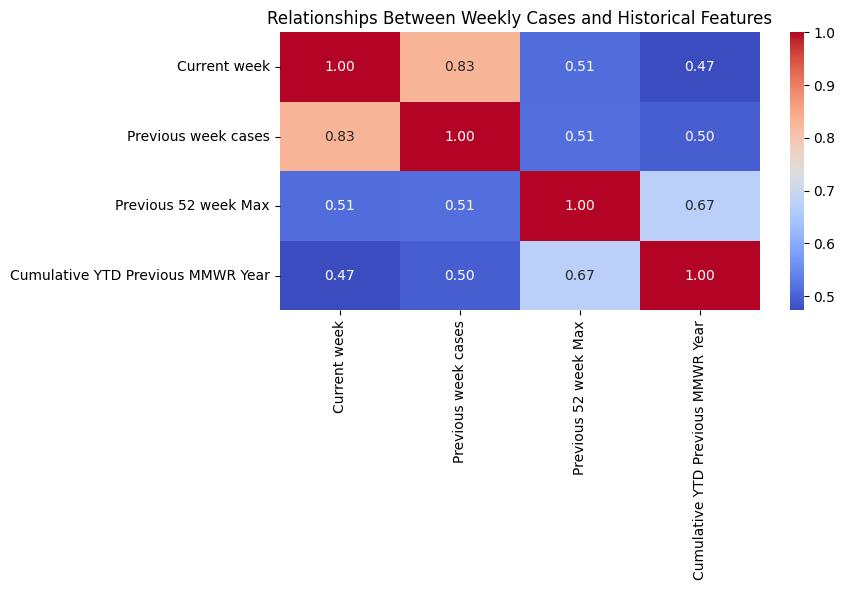

In [127]:
correlation_columns = [
    "Current week",
    "Previous week cases",
    "Previous 52 week Max",
    "Cumulative YTD Previous MMWR Year",
]

correlations = model_df[correlation_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

plt.title("Relationships Between Weekly Cases and Historical Features")
plt.tight_layout()
plt.show()


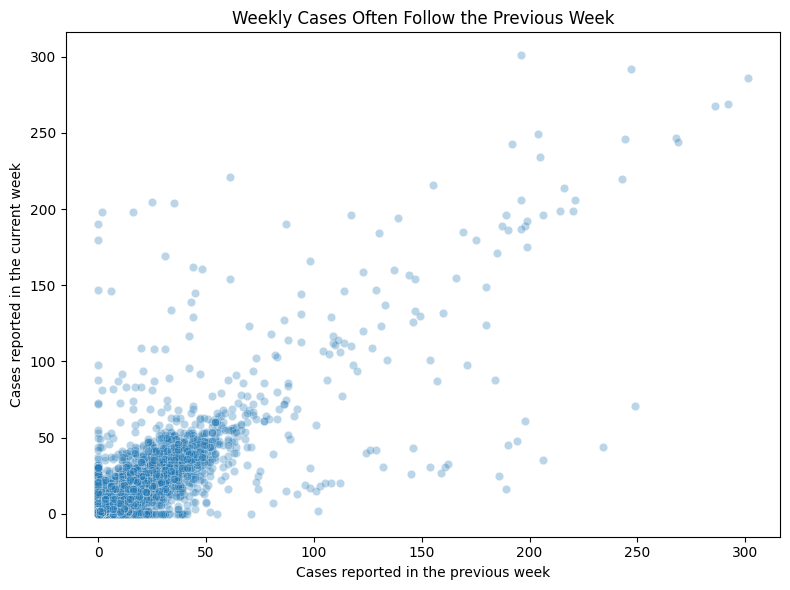

In [128]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=model_df,
    x="Previous week cases",
    y="Current week",
    alpha=0.30,
)

plt.title("Weekly Cases Often Follow the Previous Week")
plt.xlabel("Cases reported in the previous week")
plt.ylabel("Cases reported in the current week")
plt.tight_layout()
plt.show()


## Preprocess

In [129]:
target = "Current week"

categorical_features = [
    "Reporting Area",
    "Season",
]

numerical_features = [
    "Previous week cases",
    "Previous 52 week Max",
    "Cumulative YTD Previous MMWR Year",
]

features = categorical_features + numerical_features

# Sort chronologically and split by position
model_df["Time Order"] = model_df["Current MMWR Year"] * 100 + model_df["MMWR WEEK"]
model_df = model_df.sort_values("Time Order")

split_idx = int(len(model_df) * 0.8)
train_df, test_df = model_df.iloc[:split_idx], model_df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

In [130]:
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    drop='first'
)

numerical_transformer = StandardScaler()


preprocessor = ColumnTransformer(
    transformers=[
        ("Categories", categorical_transformer, categorical_features),
        ("Numbers", numerical_transformer, numerical_features),
    ]
)


<Axes: xlabel='Current week', ylabel='Count'>

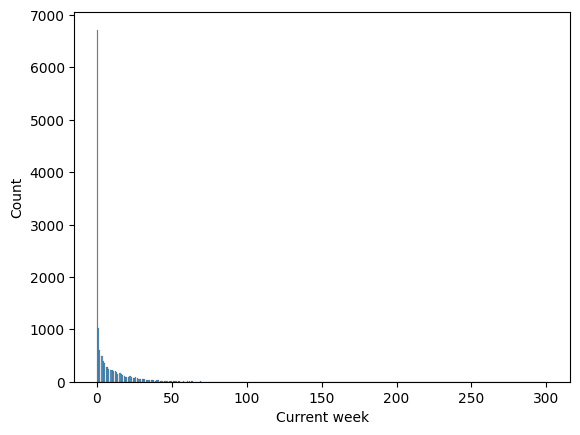

In [131]:
sns.histplot(data=model_df, x="Current week")

In [132]:
X_train.head()

,Reporting Area,Season,Previous week cases,Previous 52 week Max,Cumulative YTD Previous MMWR Year
0,ALABAMA,Winter,10.0,38.0,12.0
3888,INDIANA,Winter,0.0,7.0,16.0
3159,HAWAII,Winter,0.0,8.0,5.0
4131,IOWA,Winter,2.0,32.0,10.0
8991,NORTH DAKOTA,Winter,0.0,7.0,1.0


## Baseline

In [133]:
# fixed rule that the current week cases will be equal to the previous
baseline_predictions = X_test["Previous week cases"]

baseline_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=baseline_predictions,
    model_name="Previous-week baseline",
)

pd.DataFrame([baseline_metrics]).round(3)


,Model,MAE,RMSE,R²
0,Previous-week baseline,3.427,8.38,0.891


## Model: Linear Regression

In [134]:
linear_model = make_pipeline(
    preprocessor,
    LinearRegression(),
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=linear_predictions,
    model_name="Linear regression",
)

pd.DataFrame([linear_metrics]).round(3)


,Model,MAE,RMSE,R²
0,Linear regression,4.362,10.801,0.819


In [135]:
linear_results = evaluate_regression(
    model=linear_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Linear Regression"
)

linear_results

,Model,Data,MAE,RMSE,R²
0,Linear Regression,Train,3.853,9.318,0.636
1,Linear Regression,Test,4.362,10.801,0.819


## Model: Random Forest

In [136]:
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestRegressor(),
)

rf_pipe.fit(X_train, y_train)
forest_predictions = rf_pipe.predict(X_test)

forest_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=forest_predictions,
    model_name="Random forest",
)

pd.DataFrame([forest_metrics]).round(3)

,Model,MAE,RMSE,R²
0,Random forest,4.379,12.136,0.771


In [137]:
forest_results = evaluate_regression(
    model=rf_pipe,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest"
)

forest_results

,Model,Data,MAE,RMSE,R²
0,Random Forest,Train,1.276,3.730,0.942
1,Random Forest,Test,4.379,12.136,0.771


In [138]:
# Try different Random Forest settings
param_grid = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [10, 20, None],
    "randomforestregressor__min_samples_leaf": [2, 5]
}

# Earlier weeks train the model and later weeks validate it
time_split = TimeSeriesSplit(n_splits=5)

gridsearch = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=time_split,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Test every parameter combination
gridsearch.fit(X_train, y_train)

print("Best parameters:")
print(gridsearch.best_params_)

print(
    "Best validation MAE:",
    round(-gridsearch.best_score_, 3)
)

# Save the best fitted Random Forest
best_rf = gridsearch.best_estimator_

# Predict the future test data
gs_pred = best_rf.predict(X_test)

# Evaluate the predictions
gs_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=gs_pred,
    model_name="Tuned Random Forest"
)

pd.DataFrame([gs_metrics]).round(3)

Best parameters:
{'randomforestregressor__max_depth': 10, 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__n_estimators': 200}
Best validation MAE: 3.926


,Model,MAE,RMSE,R²
0,Tuned Random Forest,4.17,11.67,0.788


In [139]:
tuned_forest_results = evaluate_regression(
    model=best_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Tuned Random Forest"
)

tuned_forest_results

,Model,Data,MAE,RMSE,R²
0,Tuned Random Forest,Train,3.024,7.666,0.753
1,Tuned Random Forest,Test,4.170,11.670,0.788


## Explanatory Data Analysis


In [140]:
results = pd.DataFrame([
    baseline_metrics,
    linear_metrics,
    forest_metrics,
    gs_metrics
])

results = results.sort_values("MAE").reset_index(drop=True)
results.round(3)


,Model,MAE,RMSE,R²
0,Previous-week baseline,3.427,8.380,0.891
1,Tuned Random Forest,4.170,11.670,0.788
2,Linear regression,4.362,10.801,0.819
3,Random forest,4.379,12.136,0.771


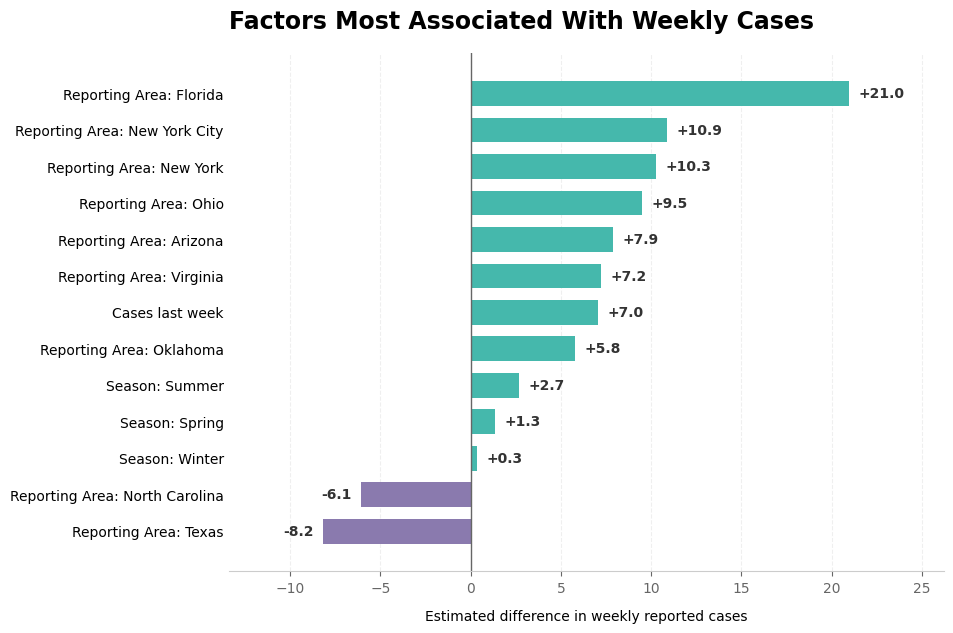

In [173]:
coefficients = plot_linear_coefficients(
    fitted_pipeline=linear_model,
    top_n=10,
    include_intercept=False,
)

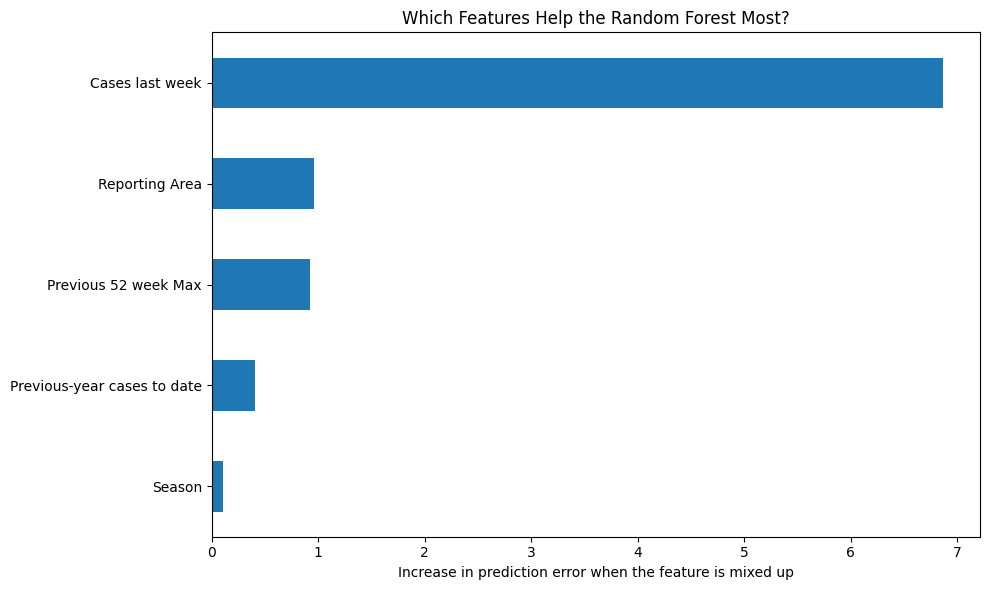

In [167]:
importance_results = permutation_importance(
    estimator=best_rf,
    X=X_test,
    y=y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_results.importances_mean,
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=True,
)

feature_importance

friendly_names = {
    "Previous week cases": "Cases last week",
    "Cumulative YTD Previous MMWR Year": "Previous-year cases to date",
}

plot_importance = feature_importance.copy()
plot_importance["Feature"] = plot_importance["Feature"].replace(friendly_names)

ax = plot_importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 6),
    legend=False,
)

ax.set_title("Which Features Help the Random Forest Most?")
ax.set_xlabel("Increase in prediction error when the feature is mixed up")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


## Neural Network

In [144]:
# Learn preprocessing rules from the training data
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

print("Training shape:", X_train_nn.shape)
print("Testing shape:", X_test_nn.shape)

Training shape: (11080, 62)
Testing shape: (2770, 62)


In [145]:
tf.keras.utils.set_random_seed(42)

nn_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(32, activation="relu"),

    # One non-negative case-count prediction
    Dense(1, activation="relu")
])

nn_model.compile(
    optimizer="adam",
    loss="mean_absolute_error",
    metrics=["mean_absolute_error"]
)

nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,145 (24.00 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.3731 - mean_absolute_error: 4.3731 - val_loss: 3.4937 - val_mean_absolute_error: 3.4937
Epoch 2/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3774 - mean_absolute_error: 3.3774 - val_loss: 3.3672 - val_mean_absolute_error: 3.3672
Epoch 3/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3315 - mean_absolute_error: 3.3315 - val_loss: 3.3817 - val_mean_absolute_error: 3.3817
Epoch 4/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3085 - mean_absolute_error: 3.3085 - val_loss: 3.3747 - val_mean_absolute_error: 3.3747
Epoch 5/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3029 - mean_absolute_error: 3.3029 - val_loss: 3.3721 - val_mean_absolute_error: 3.3721
Epoch 6/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.2687 - mean_absolute_error: 3.2687 - val_loss: 3.3697 - val_mean_absolute_error: 3.3697
Epoch 7/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.2591 - mean_absolute_error: 3.2

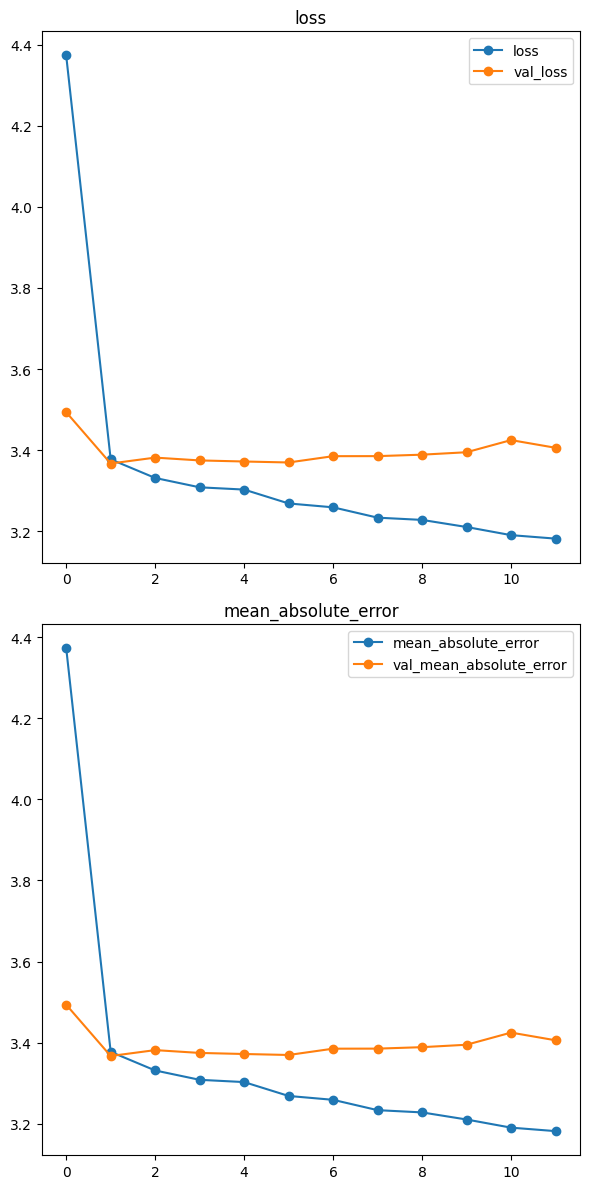

In [146]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

plot_history(history);

In [147]:
nn_predictions = nn_model.predict(
    X_test_nn,
    verbose=0
).flatten()

nn_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=nn_predictions,
    model_name="TensorFlow Neural Network"
)

pd.DataFrame([nn_metrics]).round(3)

,Model,MAE,RMSE,R²
0,TensorFlow Neural Network,3.71,10.089,0.842


In [148]:
nn_results = evaluate_regression(
    model=nn_model,
    X_train=X_train_nn,
    y_train=y_train,
    X_test=X_test_nn,
    y_test=y_test,
    model_name="Neural Network",
    neural_network=True
)

nn_results

,Model,Data,MAE,RMSE,R²
0,Neural Network,Train,3.308,9.923,0.587
1,Neural Network,Test,3.710,10.089,0.842


## Final Model

In [149]:
results = pd.DataFrame([
    baseline_metrics,
    linear_metrics,
    forest_metrics,
    gs_metrics,
    nn_metrics,
])

results = results.sort_values(
    "MAE"
).reset_index(drop=True)

results.round(3)

,Model,MAE,RMSE,R²
0,Previous-week baseline,3.427,8.380,0.891
1,TensorFlow Neural Network,3.710,10.089,0.842
2,Tuned Random Forest,4.170,11.670,0.788
3,Linear regression,4.362,10.801,0.819
4,Random forest,4.379,12.136,0.771
